# Document Summarization

In this case study we use LDA model to classify documents into topics and sub-topics.

## Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Libraries and Dataset](#1)
    * [2.1. Load Libraries](#1.1)
* [3. Data Preparation](#2)
* [4.Model Construction and Training](#4)        
* [5.Visualization of results](#5)
    * [5.1. Topic Visualization](#5.1)
    * [5.2. Word Cloud](#5.2)

<a id='0'></a>
# 1. Problem Definition

The goal of this project is to effectively discover common
topics among a large data set of 10-k filings of publicly traded companies. A 10-K is a comprehensive report filed annually by a publicly-traded company about its financial performance and is required by the U.S. Securities and Exchange Commission (SEC). The report contains much more detail than a company's annual report, which is sent to its shareholders before an annual meeting to elect company directors.
Thus, each 10-K (here we do it for only 1) will be assigned to some number of topics.


<a id='1'></a>
# 2. Getting Started - Loading the data and python packages


<a id='1.1'></a>
## 2.1. Loading the python packages

In the first step we check if the additional packages needed are present, if not install them. These are checked separately as they aren't included in requirement.txt as they aren't used for all case studies.

In [1]:
!pip freeze
# install pdfminer==20191125
# install wordcloud==1.9.3
# install pyLDAvis==2.1.2

aiohttp==3.9.5
aiosignal==1.3.1
annotated-types==0.7.0
anyio==4.4.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
arrow==1.3.0
asttokens==2.4.1
async-lru==2.0.4
attrs==23.2.0
Babel==2.15.0
beautifulsoup4==4.12.3
bleach==6.1.0
certifi==2024.2.2
cffi==1.16.0
charset-normalizer==3.3.2
click==8.1.7
cloudpickle==3.1.1
colorama==0.4.6
comm==0.2.2
contourpy==1.2.1
curl_cffi==0.13.0
cycler==0.12.1
debugpy==1.8.1
decorator==5.1.1
defusedxml==0.7.1
distro==1.9.0
et_xmlfile==2.0.0
executing==2.0.1
fastjsonschema==2.19.1
fonttools==4.53.0
fqdn==1.5.1
frozendict==2.4.6
frozenlist==1.4.1
greenlet==3.1.1
h11==0.14.0
httpcore==1.0.5
httpx==0.27.0
idna==3.6
ipykernel==6.29.4
ipython==8.25.0
isoduration==20.11.0
jedi==0.19.1
Jinja2==3.1.4
joblib==1.4.2
json5==0.9.25
jsonlines==4.0.0
jsonpointer==2.4
jsonschema==4.22.0
jsonschema-specifications==2023.12.1
jupyter-events==0.10.0
jupyter-lsp==2.2.5
jupyter_client==8.6.2
jupyter_core==5.7.2
jupyter_server==2.14.1
jupyter_server_terminals==0.5.3
jupyterla

In [3]:
# a Python library for extracting text from PDFs.
!pip install pdfminer==20191125 

     ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.2 MB 653.6 kB/s eta 0:00:07
     ---- ----------------------------------- 0.4/4.2 MB 4.5 MB/s eta 0:00:01
     ------------ --------------------------- 1.3/4.2 MB 8.9 MB/s eta 0:00:01
     ------------------------ --------------- 2.5/4.2 MB 13.5 MB/s eta 0:00:01
     ---------------------------------------  4.2/4.2 MB 19.0 MB/s eta 0:00:01
     ---------------------------------------- 4.2/4.2 MB 15.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------  1.8/1.8 MB 11


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# !pip install pyLDAvis==2.1.2
# pyLDAvis is a Python library used for visualizing topic models, especially Latent Dirichlet Allocation (LDA) models
!pip install --upgrade pyLDAvis

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ------ --------------------------------- 0.5/2.6 MB 9.4 MB/s eta 0:00:01
   ----------------- ---------------------- 1.1/2.6 MB 11.7 MB/s eta 0:00:01
   ------------------------------- -------- 2.0/2.6 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------  2.6/2.6 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------  2.6/2.6 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 9.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   -- ------------------------------------- 1.4/24.4 MB 28.5 MB/s eta 0:00:01
   --- ------------------------------------ 2.4/24.4 MB 25.1 MB/s eta 0:00:01
   ----- ---------------------------------- 3.4/24.4 MB 23.9 MB/s eta 0:00:01
   ------- -------------------------------- 4.4/24.4 MB 25.4 MB/s eta 0:00:01
   -------- ------------------------------- 5.4/24.4 MB 23.1 MB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Latent Dirichlet Allocation (LDA) is a popular topic modeling algorithm used to discover hidden topics in a collection of text documents. It assumes that:

Each document is a mixture of topics.

Each topic is a distribution over words.


How It Works

LDA assigns each word in a document to one of several topics probabilistically.
It iteratively adjusts topic distributions for words and documents to find the best fit.
The result is a set of topics, each defined by a set of words that frequently appear together.

Example

If LDA analyzes a set of news articles, it might uncover topics like:

Topic 1 (Politics): government, election, law, president

Topic 2 (Sports): football, team, game, coach

Topic 3 (Technology): AI, data, machine learning, algorithm

Use Cases

Document clustering (grouping similar articles)

Search engines (enhancing query understanding)

Social media analysis (trending topics detection)

In [6]:
# used to generate word clouds from text data.
!pip install wordcloud 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Libraries for pdf conversion
from pdfminer.pdfinterp import PDFResourceManager, PDFPageInterpreter
# PDFResourceManager -> stores shared resources such as fonts or images
# PDFPageInterpreter -> creates interpreter object -> Processes page content

from pdfminer.converter import TextConverter  # converts pdf to text
from pdfminer.layout import LAParams  # used to set the pdf layout (size, page format etc) information required for text analysis as a parameter
from pdfminer.pdfpage import PDFPage  # extract the pages from the pdf file
import re  # imports the regular expressions module, which provides functions for working with text patterns. This module allows you to search, match, and manipulate strings using regex (regular expressions).
from io import StringIO  # StringIO allows you to treat a string as a file-like object, meaning you can read from and write to it just like a file.

# Libraries for feature extraction and topic modeling
from sklearn.decomposition import LatentDirichletAllocation

# from sklearn.feature_extraction.stop_words import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words
# Other libraries
import numpy as np
import pandas as pd

In [ ]:
# Disable the warnings
import warnings
warnings.filterwarnings('ignore')

<a id='2'></a>
# 3. Data Preparation

The function defined below pulls out all characters from a pdf document except the images. The function simply takes in the name of the pdf document, extracts all characters from it and outputs the extracted texts as a python list of strings.

In [ ]:
def convert_pdf_to_txt(path):

    # initiate the Interpreter class as a text reader:
    rsrcmgr = PDFResourceManager()  # manages shared resources (such as fonts and images) when processing a PDF
    retstr = StringIO()       # It allows you to read and write strings as if they were stored in a file.
    laparams = LAParams()     # layout analysis when extracting text from PDFs. It helps control how text is grouped and formatted.
    device = TextConverter(rsrcmgr, retstr, laparams=laparams)

    # extract the pages from the pdf file:
    fp = open(path, 'rb')
    interpreter = PDFPageInterpreter(rsrcmgr, device)
    password = ""
    maxpages = 0
    caching = True
    pagenos=set()  # comma separated list of page numbers to parse

    # loop through all the pages running the interpreter:
    for page in PDFPage.get_pages(fp, pagenos, maxpages=maxpages, password=password,caching=caching, check_extractable=True):
        interpreter.process_page(page)  # receive the object for the page.

    # get all the output from the string buffer defined above
    text = retstr.getvalue()

    # tidy things up
    fp.close()
    device.close()
    retstr.close()
    return text

The pdf is converted to text using the function defined above.

 10-K file, also known as Form 10-K, is an annual report that US public companies must file with the Securities and Exchange Commission (SEC). It's a summary of a company's financial performance and business activities.

In [9]:
pwd

'C:\\Users\\Nb736\\F550 Applications AI\\Class 2'

In [ ]:
import os

folder_path = 'C:\\Users\\Nb736\\F550 Applications AI\\Class 2'
pdf_files = []
with open(os.path.join(folder_path, 'all_files.txt'), 'w') as f:  # create a file called all_files that will contain all pdfs in text form
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".pdf"):
            print(file_name)
            Document=convert_pdf_to_txt(os.path.join(folder_path, file_name))
            f.write(Document)
f.close()
with open(os.path.join(folder_path, 'all_files.txt')) as f:
    clean_cont = f.read().splitlines()  # I can split the lines OR I CAN get each word by using split()

words_pdf = Document.split()

2nd_class_First_Exercise 10K.pdf


In [ ]:
os.listdir(folder_path)  # the files inside the folder path

['.ipynb_checkpoints',
 '2nd_class_exercise-Copy1.ipynb',
 '2nd_class_exercise.ipynb',
 '2nd_class_First_Exercise 10K.pdf',
 'all_files.txt']

In [13]:
clean_cont  # get each line. \xa0-->non-breaking space (NBSP)

['UNITED STATES',
 ' ',
 '',
 'SECURITIES AND EXCHANGE COMMISSION',
 ' ',
 '',
 'Washington, D.C. 20549',
 ' ',
 '',
 '\xa0',
 'FORM ',
 '\xa0',
 '',
 'QUARTERLY REPORT PURSUANT TO SECTION 13 OR 15(d) OF',
 ' ',
 '',
 'THE SECURITIES EXCHANGE ACT OF 1934',
 ' ',
 'For the quarterly period ended September\xa030, 2016',
 ' ',
 ' ',
 '',
 'Commission file number 001-2979',
 ' ',
 '',
 '\xa0',
 '',
 '\xa0',
 '',
 'WELLS FARGO & COMPANY ',
 '',
 '(Exact name of registrant as specified in its charter) ',
 '',
 'Delaware ',
 '',
 '(State of incorporation) ',
 '',
 'No. 41-0449260 ',
 '',
 '(I.R.S. Employer Identification No.) ',
 '',
 '\xa0',
 '',
 '420 Montgomery Street, San Francisco, California 94163 ',
 '',
 '(Address of principal executive offices)\xa0 (Zip Code) ',
 '',
 '\xa0',
 '',
 'Registrant’s telephone number, including area code:\xa0 1-866-249-3302\xa0',
 '',
 '\xa0',
 'Indicate by check mark whether the registrant (1) has filed all reports required to be filed by Section 13 or 1

In [14]:
words_pdf # get each word

['UNITED',
 'STATES',
 'SECURITIES',
 'AND',
 'EXCHANGE',
 'COMMISSION',
 'Washington,',
 'D.C.',
 '20549',
 'FORM',
 'QUARTERLY',
 'REPORT',
 'PURSUANT',
 'TO',
 'SECTION',
 '13',
 'OR',
 '15(d)',
 'OF',
 'THE',
 'SECURITIES',
 'EXCHANGE',
 'ACT',
 'OF',
 '1934',
 'For',
 'the',
 'quarterly',
 'period',
 'ended',
 'September',
 '30,',
 '2016',
 'Commission',
 'file',
 'number',
 '001-2979',
 'WELLS',
 'FARGO',
 '&',
 'COMPANY',
 '(Exact',
 'name',
 'of',
 'registrant',
 'as',
 'specified',
 'in',
 'its',
 'charter)',
 'Delaware',
 '(State',
 'of',
 'incorporation)',
 'No.',
 '41-0449260',
 '(I.R.S.',
 'Employer',
 'Identification',
 'No.)',
 '420',
 'Montgomery',
 'Street,',
 'San',
 'Francisco,',
 'California',
 '94163',
 '(Address',
 'of',
 'principal',
 'executive',
 'offices)',
 '(Zip',
 'Code)',
 'Registrant’s',
 'telephone',
 'number,',
 'including',
 'area',
 'code:',
 '1-866-249-3302',
 'Indicate',
 'by',
 'check',
 'mark',
 'whether',
 'the',
 'registrant',
 '(1)',
 'has',
 '

In [15]:
len(words_pdf) # number of words

96587

Note : Students should try to exclude some words here

In [16]:
doc=[i.replace('\xe2\x80\x9c','') for i in words_pdf ]   #  LEFT DOUBLE QUOTATION MARK # in UTF-8 bytes (encoded)
doc=[i.replace('\xe2\x80\x9d','') for i in doc ]
doc=[i.replace('\xe2\x80\x99s','') for i in doc ]

docs = [x for x in doc if x != ' ']
docss = [x for x in docs if x != '']
financedoc=[re.sub("[^a-zA-Z]+", " ", s) for s in docss]

# removes all non-alphabetic characters and replacing them with spaces. The caret ("^") is used in two different ways, one to signal the start of the text, one to negate a character match inside square brackets.

# ^[a-zA-Z] means any a-z or A-Z at the start of a line

# [^a-zA-Z] means any character that IS NOT a-z OR A-Z

# ^ means "start of string", and $ is "end of string". These are called "anchors".  + means "one or more" and * means "zero or more"


In [17]:
financedoc

['UNITED',
 'STATES',
 'SECURITIES',
 'AND',
 'EXCHANGE',
 'COMMISSION',
 'Washington ',
 'D C ',
 ' ',
 'FORM',
 'QUARTERLY',
 'REPORT',
 'PURSUANT',
 'TO',
 'SECTION',
 ' ',
 'OR',
 ' d ',
 'OF',
 'THE',
 'SECURITIES',
 'EXCHANGE',
 'ACT',
 'OF',
 ' ',
 'For',
 'the',
 'quarterly',
 'period',
 'ended',
 'September',
 ' ',
 ' ',
 'Commission',
 'file',
 'number',
 ' ',
 'WELLS',
 'FARGO',
 ' ',
 'COMPANY',
 ' Exact',
 'name',
 'of',
 'registrant',
 'as',
 'specified',
 'in',
 'its',
 'charter ',
 'Delaware',
 ' State',
 'of',
 'incorporation ',
 'No ',
 ' ',
 ' I R S ',
 'Employer',
 'Identification',
 'No ',
 ' ',
 'Montgomery',
 'Street ',
 'San',
 'Francisco ',
 'California',
 ' ',
 ' Address',
 'of',
 'principal',
 'executive',
 'offices ',
 ' Zip',
 'Code ',
 'Registrant s',
 'telephone',
 'number ',
 'including',
 'area',
 'code ',
 ' ',
 'Indicate',
 'by',
 'check',
 'mark',
 'whether',
 'the',
 'registrant',
 ' ',
 'has',
 'filed',
 'all',
 'reports',
 'required',
 'to',
 'be'

In [18]:
len(financedoc)

96587

In [19]:
sklearn_stop_words

frozenset({'a',
           'about',
           'above',
           'across',
           'after',
           'afterwards',
           'again',
           'against',
           'all',
           'almost',
           'alone',
           'along',
           'already',
           'also',
           'although',
           'always',
           'am',
           'among',
           'amongst',
           'amoungst',
           'amount',
           'an',
           'and',
           'another',
           'any',
           'anyhow',
           'anyone',
           'anything',
           'anyway',
           'anywhere',
           'are',
           'around',
           'as',
           'at',
           'back',
           'be',
           'became',
           'because',
           'become',
           'becomes',
           'becoming',
           'been',
           'before',
           'beforehand',
           'behind',
           'being',
           'below',
           'beside',
           'besides'

In [20]:
# exclude the stop words -> such that am/is/or/but/and etc
tokens_without_sw= [word for word in financedoc if not word in sklearn_stop_words ]
len(tokens_without_sw)

71547

The text extracted from the pdf document contains uninformative characters which needs to be removed.

<a id='4'></a>
# 4. Model construction using LDA AND visualization

In [ ]:
# Install SpaCy
!python -m pip install -U pip setuptools wheel
!python -m pip install -U spacy

In [25]:
import gensim # Gensim is an open-source library for unsupervised topic modeling, document indexing, retrieval by similarity, and other natural language processing functionalities, using modern statistical machine learning.
import gensim.corpora as corpora #   It provides tools to create, manage, and transform text data into numerical representations
from gensim.corpora import Dictionary # This module implements the concept of a Dictionary – a mapping between words and their integer ids.
from gensim.models.coherencemodel import CoherenceModel   #  Calculate topic coherence for topic models.
from gensim.models.ldamodel import LdaModel   #  Calculate topic coherence for topic models.

from pprint import pprint   # The pprint module provides a capability to “pretty-print” arbitrary Python data structures in a form which can be used as input to the interpreter

# spyCy is for NLP tasks, with features like tagging, parsing, NER, and more.
import spacy #  spaCy is library for advanced natural language processing

# see this YouTube Video to understand "pickle": https://www.youtube.com/watch?v=XzkhtWYYojg&t=320s
import pickle
import re
import pyLDAvis
import pyLDAvis.gensim

import matplotlib.pyplot as plt
import pandas as pd

In [26]:
words_pdf1 = [t.split(',') for t in tokens_without_sw ]

In [27]:
len(tokens_without_sw)

71547

In [28]:
financedoc

['UNITED',
 'STATES',
 'SECURITIES',
 'AND',
 'EXCHANGE',
 'COMMISSION',
 'Washington ',
 'D C ',
 ' ',
 'FORM',
 'QUARTERLY',
 'REPORT',
 'PURSUANT',
 'TO',
 'SECTION',
 ' ',
 'OR',
 ' d ',
 'OF',
 'THE',
 'SECURITIES',
 'EXCHANGE',
 'ACT',
 'OF',
 ' ',
 'For',
 'the',
 'quarterly',
 'period',
 'ended',
 'September',
 ' ',
 ' ',
 'Commission',
 'file',
 'number',
 ' ',
 'WELLS',
 'FARGO',
 ' ',
 'COMPANY',
 ' Exact',
 'name',
 'of',
 'registrant',
 'as',
 'specified',
 'in',
 'its',
 'charter ',
 'Delaware',
 ' State',
 'of',
 'incorporation ',
 'No ',
 ' ',
 ' I R S ',
 'Employer',
 'Identification',
 'No ',
 ' ',
 'Montgomery',
 'Street ',
 'San',
 'Francisco ',
 'California',
 ' ',
 ' Address',
 'of',
 'principal',
 'executive',
 'offices ',
 ' Zip',
 'Code ',
 'Registrant s',
 'telephone',
 'number ',
 'including',
 'area',
 'code ',
 ' ',
 'Indicate',
 'by',
 'check',
 'mark',
 'whether',
 'the',
 'registrant',
 ' ',
 'has',
 'filed',
 'all',
 'reports',
 'required',
 'to',
 'be'

In [29]:
final_data = list(filter(lambda x: x != ' ', tokens_without_sw))

In [30]:
final_data

['UNITED',
 'STATES',
 'SECURITIES',
 'AND',
 'EXCHANGE',
 'COMMISSION',
 'Washington ',
 'D C ',
 'FORM',
 'QUARTERLY',
 'REPORT',
 'PURSUANT',
 'TO',
 'SECTION',
 'OR',
 ' d ',
 'OF',
 'THE',
 'SECURITIES',
 'EXCHANGE',
 'ACT',
 'OF',
 'For',
 'quarterly',
 'period',
 'ended',
 'September',
 'Commission',
 'file',
 'number',
 'WELLS',
 'FARGO',
 'COMPANY',
 ' Exact',
 'registrant',
 'specified',
 'charter ',
 'Delaware',
 ' State',
 'incorporation ',
 'No ',
 ' I R S ',
 'Employer',
 'Identification',
 'No ',
 'Montgomery',
 'Street ',
 'San',
 'Francisco ',
 'California',
 ' Address',
 'principal',
 'executive',
 'offices ',
 ' Zip',
 'Code ',
 'Registrant s',
 'telephone',
 'number ',
 'including',
 'area',
 'code ',
 'Indicate',
 'check',
 'mark',
 'registrant',
 'filed',
 'reports',
 'required',
 'filed',
 'Section',
 ' d ',
 'Securities',
 'Exchange',
 'Act',
 'preceding',
 'months',
 ' or',
 'shorter',
 'period',
 'registrant',
 'required',
 'file',
 'reports ',
 'subject',
 'f

In [31]:
# Creates a Gensim dictionary (a mapping) from tokens in final_data to integer IDs.
# Internally it builds id2word.token2id (e.g., {"A": 0, "B": 1, ...}) and the inverse mapping.

# id2word.doc2bow([" A B "])
# Converts the given “document” into a bag-of-words representation: a list of (token_id, count) pairs using that dictionary.

#Important: you are passing a list with one string token (" A B "), not two tokens ["A","B"]. So the output will be either:
# [] if " A B " is not an exact token in the dictionary, or
# [(some_id, 1)] if that exact string exists as a token.

id2word = corpora.Dictionary([final_data])
id2word.doc2bow([" A B "]) # CHECK  id2word.token2id for the direct mapping

[(1, 1)]

In [32]:
id2word.token2id

{' A ': 0,
 ' A B ': 1,
 ' A C ': 2,
 ' A D ': 3,
 ' ABS ': 4,
 ' ACL ': 5,
 ' ARM ': 6,
 ' ARS ': 7,
 ' ASC ': 8,
 ' ASU': 9,
 ' ASU ': 10,
 ' AUA ': 11,
 ' AUM ': 12,
 ' AVM ': 13,
 ' AVMs ': 14,
 ' Accrued': 15,
 ' Address': 16,
 ' Amendments': 17,
 ' Assets ': 18,
 ' August': 19,
 ' B ': 20,
 ' B C ': 21,
 ' B D ': 22,
 ' BCBS ': 23,
 ' BHC ': 24,
 ' BHCs ': 25,
 ' Balance': 26,
 ' Bank ': 27,
 ' Board ': 28,
 ' Brexit ': 29,
 ' Business': 30,
 ' C ': 31,
 ' C D ': 32,
 ' CAL': 33,
 ' CCAR ': 34,
 ' CDOs ': 35,
 ' CDR ': 36,
 ' CDS ': 37,
 ' CECL ': 38,
 ' CET ': 39,
 ' CFEs ': 40,
 ' CFPB ': 41,
 ' CLO CDO ': 42,
 ' CLOs ': 43,
 ' CLTV ': 44,
 ' CLTV We': 45,
 ' CMBS ': 46,
 ' CPP ': 47,
 ' CPR ': 48,
 ' CRC ': 49,
 ' CRE ': 50,
 ' CVA ': 51,
 ' Capital': 52,
 ' Carrying': 53,
 ' Cash': 54,
 ' Corporate': 55,
 ' Critical': 56,
 ' Customer': 57,
 ' D ': 58,
 ' D A ': 59,
 ' D B ': 60,
 ' DEF': 61,
 ' DEP ': 62,
 ' DIF ': 63,
 ' DPD ': 64,
 ' DPLCs ': 65,
 ' Day': 66,
 ' Denotes': 6

In [34]:
# create dictionary (same as above!)
id2word = corpora.Dictionary([final_data]) #   a mapping between words and their integer ids.

# create corpus
corpus = [id2word.doc2bow(text) for text in [final_data]]  # Convert document into the bag-of-words (BoW) format = list of (token_id, token_count) tuples.
# gives--> id and frequency
# test
# Each tuple (k, v) means: token with ID k appears v times in that document.
print(corpus[:])

[[(0, 10), (1, 3), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 1), (9, 2), (10, 1), (11, 1), (12, 1), (13, 1), (14, 2), (15, 2), (16, 1), (17, 3), (18, 1), (19, 2), (20, 7), (21, 1), (22, 1), (23, 2), (24, 1), (25, 1), (26, 2), (27, 1), (28, 1), (29, 1), (30, 2), (31, 2), (32, 1), (33, 1), (34, 1), (35, 2), (36, 1), (37, 1), (38, 1), (39, 2), (40, 1), (41, 2), (42, 1), (43, 1), (44, 2), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 2), (51, 1), (52, 5), (53, 1), (54, 1), (55, 1), (56, 3), (57, 1), (58, 2), (59, 1), (60, 1), (61, 1), (62, 2), (63, 1), (64, 1), (65, 1), (66, 3), (67, 2), (68, 1), (69, 13), (70, 2), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 6), (78, 1), (79, 1), (80, 1), (81, 1), (82, 2), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 11), (89, 1), (90, 3), (91, 1), (92, 1), (93, 12), (94, 2), (95, 3), (96, 1), (97, 1), (98, 3), (99, 4), (100, 6), (101, 1), (102, 1), (103, 1), (104, 1), (105, 1), (106, 1), (107, 1), (108, 1), (109, 4), (110

In [35]:
[[(id2word[i], freq) for i, freq in doc] for doc in corpus[:1]]

[[(' A ', 10),
  (' A B ', 3),
  (' A C ', 1),
  (' A D ', 1),
  (' ABS ', 1),
  (' ACL ', 1),
  (' ARM ', 1),
  (' ARS ', 2),
  (' ASC ', 1),
  (' ASU', 2),
  (' ASU ', 1),
  (' AUA ', 1),
  (' AUM ', 1),
  (' AVM ', 1),
  (' AVMs ', 2),
  (' Accrued', 2),
  (' Address', 1),
  (' Amendments', 3),
  (' Assets ', 1),
  (' August', 2),
  (' B ', 7),
  (' B C ', 1),
  (' B D ', 1),
  (' BCBS ', 2),
  (' BHC ', 1),
  (' BHCs ', 1),
  (' Balance', 2),
  (' Bank ', 1),
  (' Board ', 1),
  (' Brexit ', 1),
  (' Business', 2),
  (' C ', 2),
  (' C D ', 1),
  (' CAL', 1),
  (' CCAR ', 1),
  (' CDOs ', 2),
  (' CDR ', 1),
  (' CDS ', 1),
  (' CECL ', 1),
  (' CET ', 2),
  (' CFEs ', 1),
  (' CFPB ', 2),
  (' CLO CDO ', 1),
  (' CLOs ', 1),
  (' CLTV ', 2),
  (' CLTV We', 1),
  (' CMBS ', 1),
  (' CPP ', 1),
  (' CPR ', 1),
  (' CRC ', 1),
  (' CRE ', 2),
  (' CVA ', 1),
  (' Capital', 5),
  (' Carrying', 1),
  (' Cash', 1),
  (' Corporate', 1),
  (' Critical', 3),
  (' Customer', 1),
  (' D ', 2

In [39]:

lda_model = LdaModel(corpus=corpus,
                   id2word=id2word,
                   num_topics=2,
                   random_state=100,
                   update_every=1,
                   chunksize=10,
                   alpha='auto')

# corpus (iterable of list of (int, float), optional) – Stream of document vectors or sparse matrix of shape (num_documents, num_terms).
# num_topics (int, optional) – The number of requested latent topics to be extracted from the training corpus.
# id2word ({dict of (int, str), gensim.corpora.dictionary.Dictionary}) – Mapping from word IDs to words. It is used to determine the vocabulary size, as well as for debugging and topic printing.

# random_state=100  --> sets the RNG seed for reproducible results.
# In LDA, alpha (α) is the Dirichlet prior over a document’s topic proportions 𝜃_𝑑. It controls how topics are mixed within each document.
# Small α (e.g., < 1): documents tend to use few topics (sparser topic mixtures). Large α (> 1): documents tend to use many topics more evenly.
# In Gensim: alpha='auto' means the model learns α from the data during training, rather than you fixing it.


In [40]:
lda_model

In [41]:
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.010*"Total" + 0.009*"billion" + 0.009*"loans" + 0.008*"The" + '
  '0.007*"September" + 0.007*"value" + 0.007*"credit" + 0.007*"income" + '
  '0.006*"mortgage" + 0.006*"assets"'),
 (1,
  '0.012*"securities" + 0.010*"Total" + 0.010*"loans" + 0.008*"September" + '
  '0.008*"assets" + 0.006*"The" + 0.006*"value" + 0.006*"Table" + '
  '0.006*"quarter" + 0.006*"net"')]


<a id='5.1'></a>
## Topics Visualization

Topic visualization facilitates the evaluation of topic quality using human judgment.
pyLDAvis is library that displays the global relationships between topics while also facilitating their
semantic evaluation by inspecting the terms most closely associated with each topic and,
inversely, the topics associated with each term. It also addresses the challenge that terms
that are frequent in a corpus tend to dominate the multinomial distribution over words that
define a topic. The PyldaVis library was used to visualize the topic models.

In [42]:
pyLDAvis.enable_notebook()
pyLDAvis.gensim.prepare(lda_model, corpus, id2word)

PreparedData(topic_coordinates=             x    y  topics  cluster       Freq
topic                                          
1      0.00297  0.0       1        1  67.876142
0     -0.00297  0.0       2        1  32.123858, topic_info=            Term        Freq       Total Category  logprob  loglift
2372     billion  325.000000  325.000000  Default  30.0000  30.0000
1861         The  349.000000  349.000000  Default  29.0000  29.0000
4138    mortgage  260.000000  260.000000  Default  28.0000  28.0000
3661      income  269.000000  269.000000  Default  27.0000  27.0000
2794      credit  299.000000  299.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
5084  securities   94.458501  493.400891   Topic2  -5.1432  -0.5176
4684     quarter   68.260371  268.584613   Topic2  -5.4681  -0.2343
774     December   59.445077  207.680669   Topic2  -5.6063  -0.1154
4179         net   65.584998  261.746799   Topic2  -5.5080  -0.2485
5024        risk   57.136476  195.960711   Topic2  -5.6459  -0.0969

[183 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
169       1  0.400184         RWAs 
169       2  0.400184         RWAs 
209       1  0.502506   annualized 
209       2  0.402005   annualized 
280       1  0.476760   ineffective
...     ...       ...           ...
5468      2  0.289369       trading
5602      1  0.656505         value
5602      2  0.345047         value
5700      1  0.736333          year
5700      2  0.264620          year

[252 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1])

This document term matrix was used as the input data to be used by the Latent Dirichlet Allocation algorithm for topic modeling. The algorithm was fitted to isolate 3-distinct topic contexts as shown by the code below. This value can definitely be altered depending on the level of granularity one intends to obtain from the modeling.

Each topic in the table above is expected to represent a broader theme. However, given we trained the model on only on one document the theme within the topics may not be very distinct from each other. Topic-1 discusses quarters, months and  currency units related to asset valuation.  

<a id='5'></a>
# 5. Vizualisation of Topics - WordCloud

The display used for the purpose of the book is shown below.

We notice that topic 1, topic 2 and 3 are quite distant from each other. This is what we observed in the section above from the words and overall theme of these topics.


<a id='5.2'></a>
## 5. WordCloud

A wordcloud was also generated for the entire legal document to note the most recurrent terms in the document as shown in the figure below.

In [43]:
from os import path
from PIL import Image  # PIL (pillow) is the Python Imaging Library
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS

In [44]:
d = path.dirname(__name__)

In [47]:
text = open(path.join(d, 'C:\\Users\\Nb736\\F550 Applications AI\\Class 2\\all_files.txt')).read()

In [48]:
stopwords = set(STOPWORDS)
wc = WordCloud(background_color="red", max_words=20, stopwords=stopwords)
wc.generate(text)

In [49]:
stopwords


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

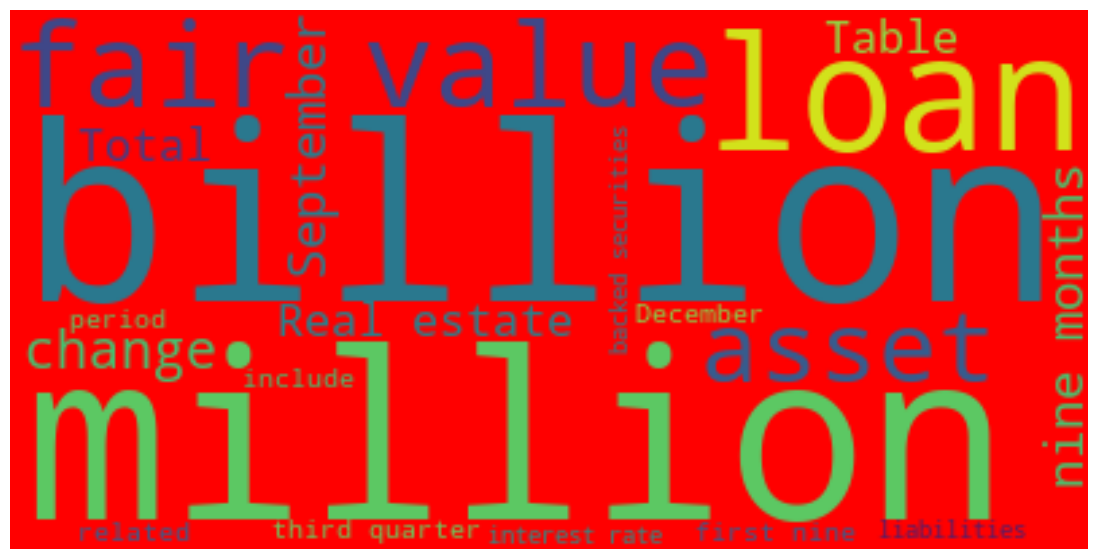

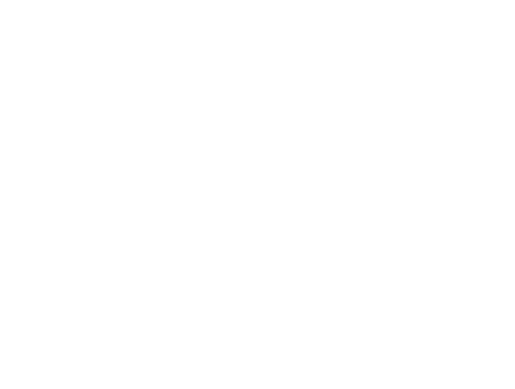

In [ ]:
plt.figure(figsize=(16,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.figure()
# plt.imshow(raw_pic, cmap=plt.cm.gray, interpolation='bilinear')
plt.axis("off")
plt.show()

The word cloud generally agrees with the results from the topic modeling as words like : Quarter, September etc are seen to be recurrent and hence bolder .


**Conclusion**

In this case study, we demonstrated the use of LDA model that extracts plausible
topics that allow us to gain a high-level understanding of large amounts of text in an
automated way, while also identifying relevant documents in a targeted way.

Overall, the case study shows how machine learning and NLP can be applied across
many domains such as investment analysis, asset modeling, risk management, regulatory and legal compliance to summarize documents, news and reports and significantly reduce the manual processing.

